In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## Importing Data 

In [3]:
df = pd.read_csv("smartcart_customers.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

# Data Preprocessing

## 1. Handling Missing Values

In [5]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 2. Feature Engineering

#### i. Add New Columns

In [8]:
# Why we are converting date realted data?
# because clustering algorithm can't handle the date data very well , It can handle only the 
# numerical data well , so that's why we are converting them to numbers.

In [9]:
# convert the year_birth to age as it will be more useful to recommend products according to age.

# New Column - Age 

df["Age"] = 2026 - df["Year_Birth"]

In [10]:
# converting the Dt_customer(joining date) to customer tenure days(total days after joining)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

In [11]:
df["Cust_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Cust_Tenure_Days'],
      dtype='object')

In [13]:
# Spending - Combining all of the spending column into one column.

df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [14]:
# Children - We have two column for kids -> kid and teen, we also will combine them 

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [16]:
df["Education"].value_counts()

# removing all these and subsituting with them -> Undergraduate,Graduate,PostGraduate
# Undergraduate -> 2n cycle,basic
# Graduate -> Graduation
# PostGraduate -> PhD, Master
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , "2n Cycle":"Undergraduate",
    "Graduation" : "Graduate", "PhD" : "PostGraduate",
    "Master" : "PostGraduate"
})

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
df["Marital_Status"].value_counts()

# same as for education

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together":"Partner",
    "Single" : "Alone", "Divorced" : "Alone",
    "Widow" : "Alone", "Alone":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

#### ii. Drop Unecessary Columns

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [19]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]

spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts",
                 "MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

df_cleaned.shape

(2240, 15)

In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

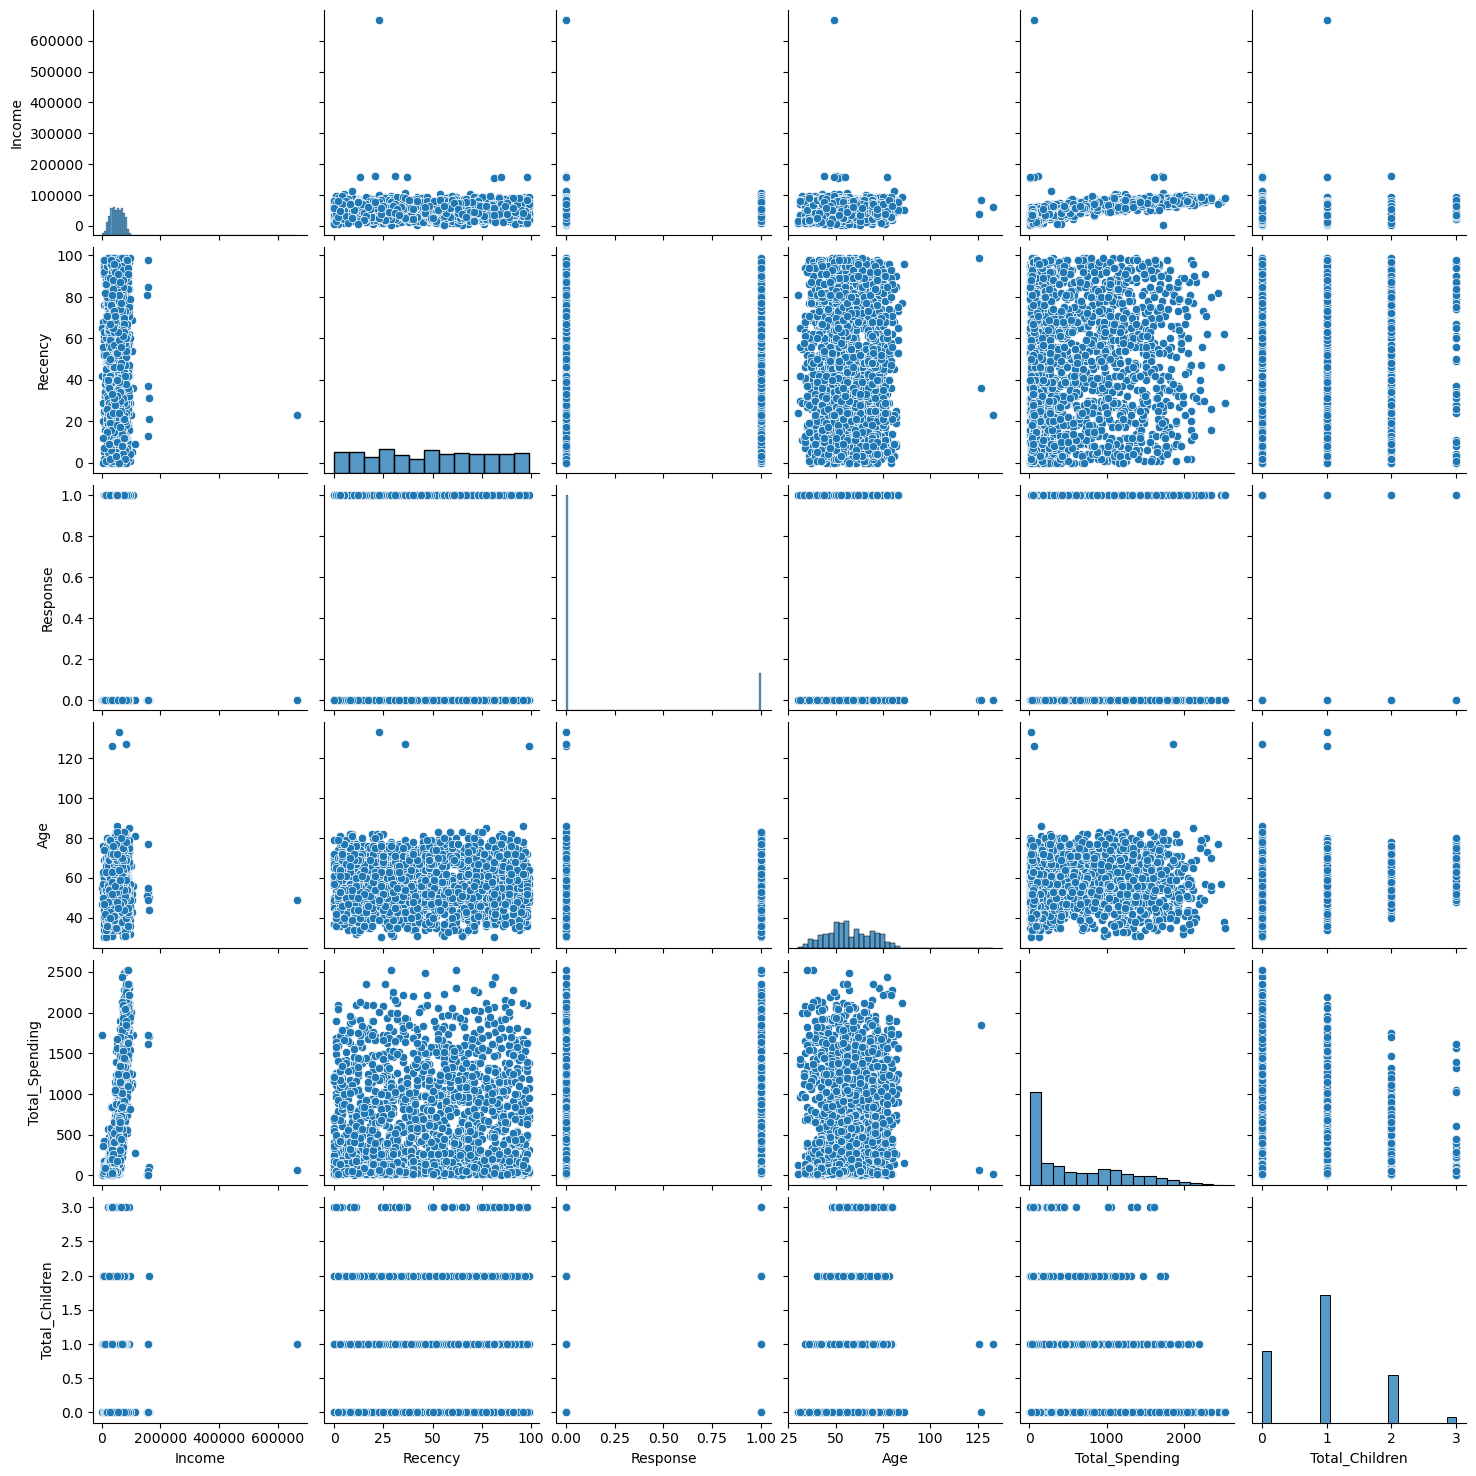

In [21]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

sns.pairplot(df_cleaned[cols])

In [22]:
# 1st outlier to remove -> user with 600000+ income 
# 2nd outlier to remove -> user with 120+ age

# Removing Outlier

print("Data size with outlier:",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("Data size without outlier:",len(df_cleaned))

Data size with outlier: 2240
Data size without outlier: 2236


# Correlation Heatmap

<Axes: >

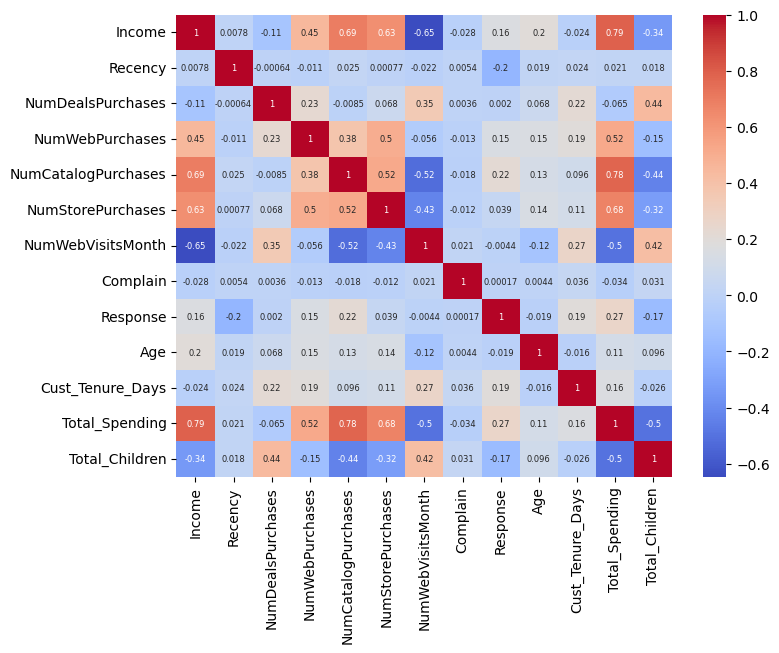

In [23]:
corr = df_cleaned.corr(numeric_only = True)

plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm")

In [24]:
# Positive Correlation
    # 0.79 -> Income - Total_Spending
    # 0.69 -> Income - Catalog purchases
    # 0.63 -> Income - Store purchases
    # 0.78 -> Total Spending - Catalog purchases
    # 0.68 -> Total Spending - Store purchases
# Negative Correlation
    # -0.65 -> Income - website visits per month 
    # -0.52 -> Catalog purchases - website visits per month
    # -0.43 -> Store purchases - website visits per month

# Encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [26]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),
             index = df_cleaned.index)

In [27]:
enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [28]:
df_encoded = pd.concat([df_cleaned.drop(columns = ["Education","Living_With"]),enc_df],axis = 1)

In [29]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Standardization

In [30]:
from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize and Dimensionality Reduction

### 1.  2D visualization

<Axes: >

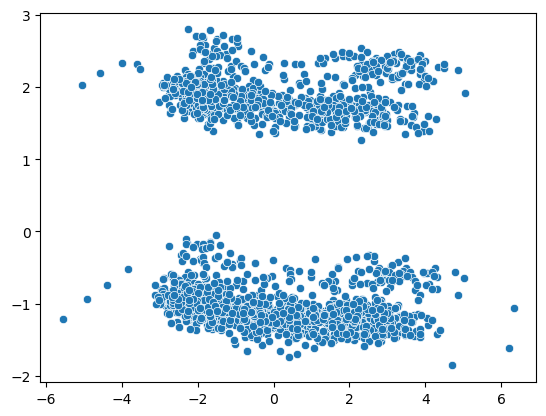

In [31]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components = 2,
    random_state = 42
)

X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x = X_pca[:,0], y = X_pca[:,1])

In [32]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

So the plot is covering 34% data of the original data which is very low.

### 2. 3D Visualization

[0.23163158 0.11385454 0.10405815]


Text(0.5, 0.92, '3D projection')

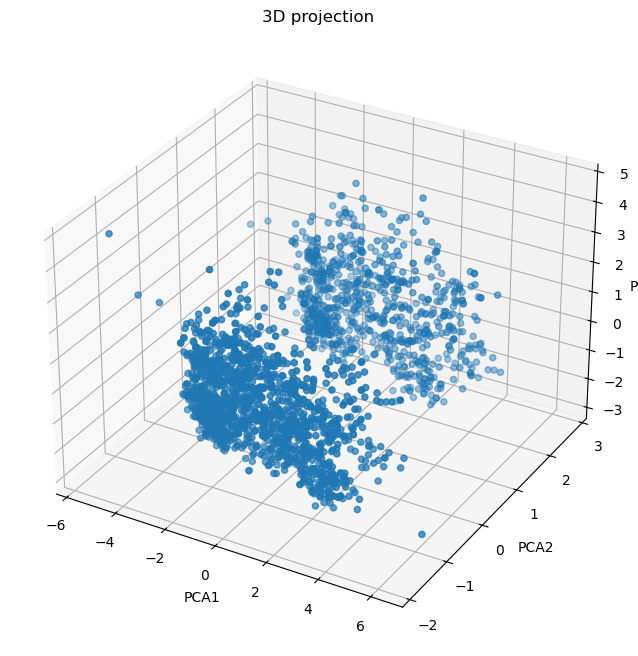

In [35]:
pca = PCA(
    n_components = 3,
    random_state = 42
)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)


fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(111,projection = "3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

ax.set_title("3D projection")

# Analyze K-Value

### 1. Elbow Method 

Best k is 4


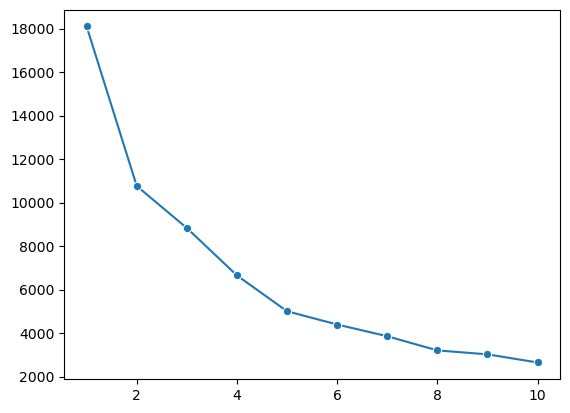

In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    model = KMeans(n_clusters = k, random_state = 42)
    model.fit_predict(X_pca)
    wcss.append(model.inertia_)

sns.lineplot(x = range(1,11), y = wcss , marker = "o")

knee = KneeLocator(range(1,11), wcss , curve = "convex", direction = "decreasing")

optimal_k = knee.elbow

print("Best k is", optimal_k)

### 2. Silhouette Score

In [37]:
from sklearn.metrics import silhouette_score
ss = []

for k in range(2,11):
    model = KMeans(n_clusters = k,random_state = 42)
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    ss.append(score)

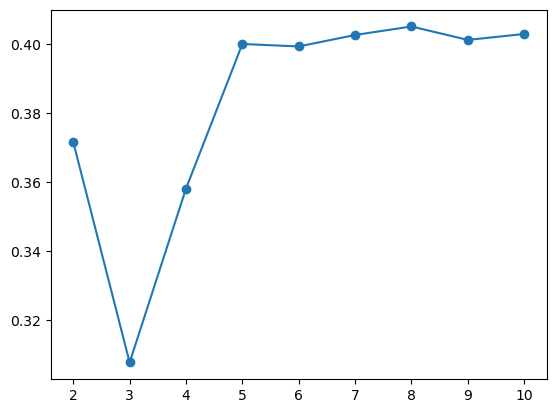

In [38]:
plt.plot(range(2,11),ss , marker = "o")

Now here for silhouette score we got 8 as the k but we try to balance the WCSS and SS and that"s why we take the nearest value where both these plot intersects(they inntersect where we got our k from elbow method) and in this it is 4, So k = 4 

Text(0, 0.5, 'SS')

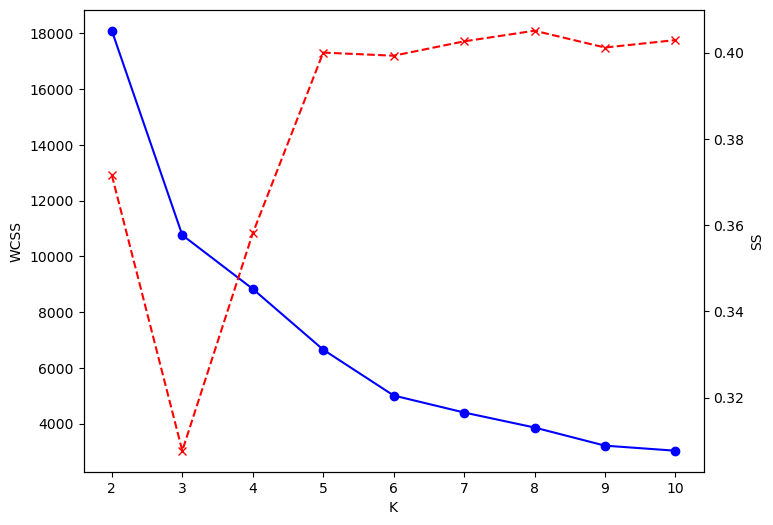

In [39]:
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker = "o", color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,ss[:len(k_range)],marker = "x", color = "red", linestyle = "--")
ax2.set_ylabel("SS")

# Clustering

## K-Means

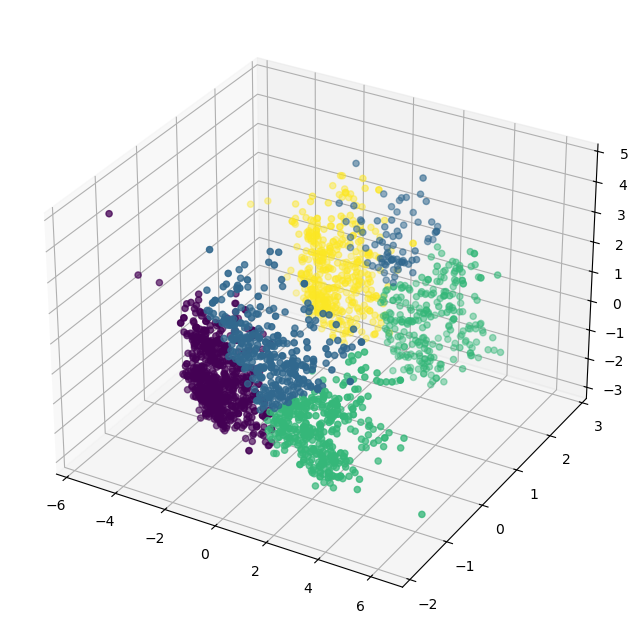

In [40]:
model = KMeans(n_clusters = 4,random_state = 42)

labels_kmeans = model.fit_predict(X_pca)

fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(111,projection = "3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_kmeans)

## Agglomerative

Text(0.5, 1.0, 'Dendrogram for hierarchical clustering')

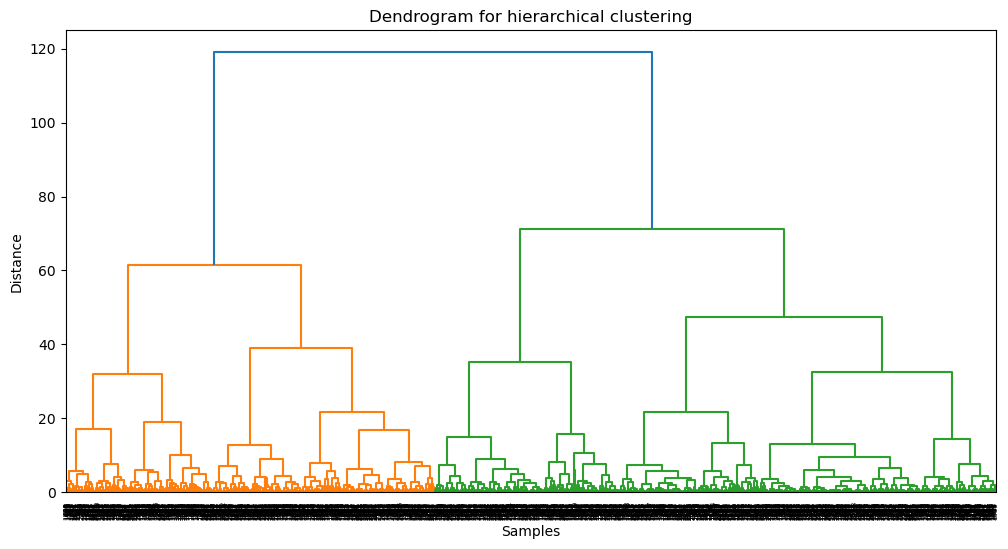

In [41]:
from scipy.cluster.hierarchy import linkage,dendrogram

# Linkage matrix

Z = linkage(X_pca, method = "ward")

# Dendrogram 

plt.figure(figsize = (12,6))
dendrogram(Z)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Dendrogram for hierarchical clustering")

## Agglomerative

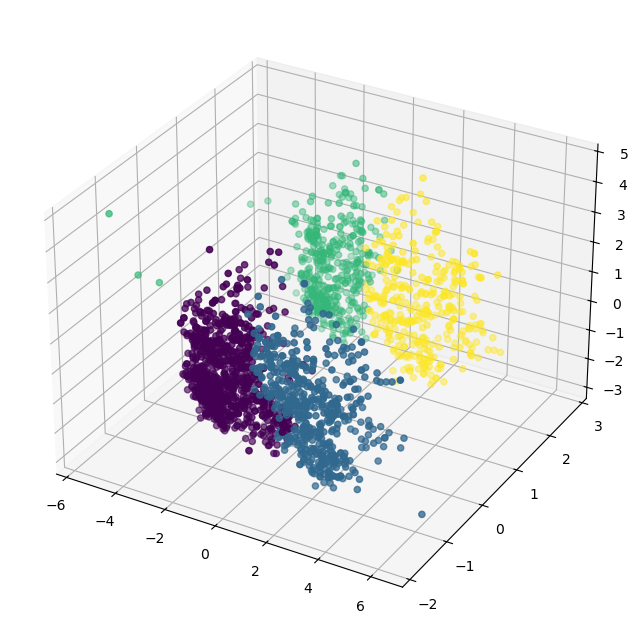

In [42]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agglo = model.fit_predict(X_pca)

fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(111,projection = "3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_agglo)

#### So, here we can the cluster separation in Agglomerative Clustering is better than K-Means.So, we will proceed with Agglomerative Clustering 

# Characterization of Clusters

In [49]:
df_cleaned["Clusters"] = labels_agglo

df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cust_Tenure_Days,Total_Spending,Total_Children,Living_With,Clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='Clusters', ylabel='count'>

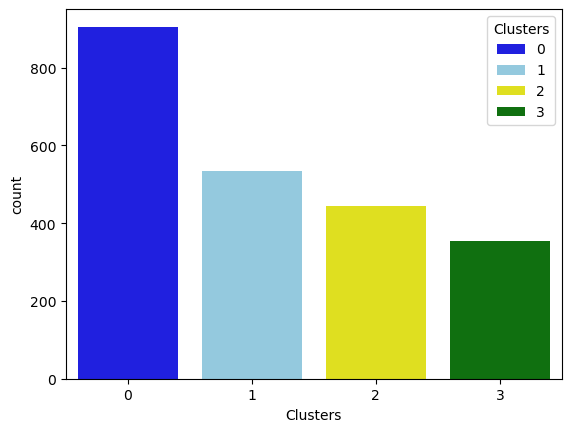

In [57]:
pal = ["Blue","skyblue","yellow","green"]

sns.countplot(x = df_cleaned["Clusters"], palette = pal, hue = df_cleaned["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

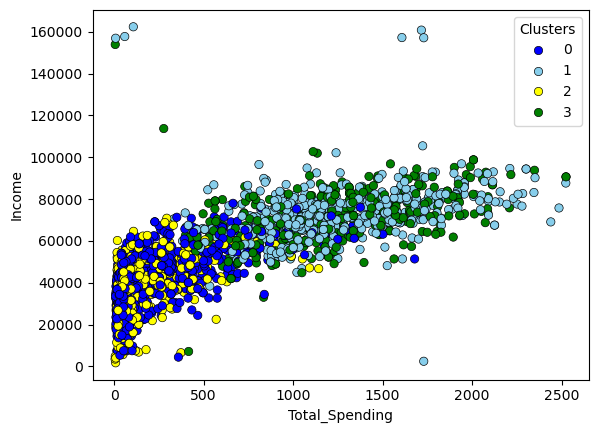

In [58]:
# Income and Total Spending pattern

sns.scatterplot(x = df_cleaned["Total_Spending"],y = df_cleaned["Income"],
                hue = df_cleaned["Clusters"], palette = pal,edgecolor = "black")

Cluster 0(BLUE) : has low-medium income range and moderate spending range.

Cluster 1(SKYBLUE) : has low-medium income range but some cases have high income(So, overall moderate to high income) and has high spending range.

Cluster 2(YELLOW) : has low income and low spending.

Cluster 3(GREEN) : has overall moderate income and moderate to high spending.

# Cluster Summary 

In [60]:
df_encoded["Clusters"] = labels_agglo 

cluster_summary = df_encoded.groupby("Clusters").mean()

# here we df_encoded instead of df_cleaned because df_cleaned has string data also for which 
# mean can't be performed.

print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Cust_Tenure_Days  Total_Spending  \
Cluster

##### now we can verify that the cluster 1 and cluster 3 has high income and high spending.

### more summary 

Cluster 0 : 1. moderate income and low spending.
            2. more number of children at home.
            3. has low average age.
            4. has poor response.
            5. live with partner.
            6. web visits are high but web purchases are low.
            
Cluster 1 : 1. high income and high spending.
            2. less number of children at home.
            3. has high average age.
            4. has average response.
            5. live with partner.
            6. web visits are low but web purchase are high and offline purchases also high.
            
Cluster 2 : 1. low income and low spending.
            2. more number of children at home.
            3. has low average age.
            4. has average response.
            5. most of them are living alone but not all.
            6. web visits are high but web purchases are low.

Cluster 3 : 1. moderate-high income and moderate-high spending.
            2. less number of children at home.
            3. has high average age.
            4. has best response.
            5. live alone.
            6. web visits are low but web purchase are high and offline purchases also high. 

So, customer who have less number of children are tend to spend more and have more income in comparison to customer with high number of children. 

So, customer with low-medium income are tend to visits website often but do not purchase from there often.

Customer with low income tends to buy items in deals.

Customer with high income tends to buy more whether it is offline or online.

Cluster 0 are family shoppers -> we can provide them discount/coupons and Deals on items.
 
Cluster 1 are high spending customer -> we can provide them some Loyality program as of their purchases.

Cluster 2 are most probably single parents with high responsibility that's why their spending is low -> we can target them for sales as they tend to buy more in deals(sale).

Cluster 3  these customers are the gold customer as they have high spending and purchases from both offline and online but they also have best response to shop offers and announcements.So, this cluster has the best ROI and we should focus on them more.